In [ ]:
%load_ext autoreload
%autoreload 2

### Imports

In [1]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from roar import ALL_VEHICLES, MIC_CHANNELS, MIC_CHANNELS_CLEANED, ROOT_DIR
from roar import DATA_DIR as DATA_ROOT
from roar.preprocessing import (
    extract_features_from_h5_file,
    fix_channel_names,
    get_channel_mapping,
    parse_filename,
)

device = (
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

### Settings

In [2]:
LOGO_COLUMN = "vehicle"
# LOGO_COLUMN = "measure"

### Mappings

In [3]:
TRACKS = ["track150", "track211"]
CARS = ALL_VEHICLES
TYRES = ["tyre1", "tyre3", "tyre6", "tyre10", "tyre12", "tyre13"]

In [4]:
# Set the data root
if not DATA_ROOT.exists():
    DATA_ROOT = Path(r"C:\Users\Lars\Büro\KIT\Master\WS_25_26\AIFB_Seminar\projects\workspace\data")

SYNONYM_TO_CHANNEL = get_channel_mapping()

h5_paths = list(DATA_ROOT.rglob("*.h5"))  # pyright: ignore[reportPossiblyUnboundVariable]
print(f"Found {len(h5_paths)} files")

for h5_path in h5_paths:
    fix_channel_names(file_path=h5_path, mapping=SYNONYM_TO_CHANNEL, verbose=False)

Found 204 files


### Build dataset

In [5]:
from tqdm import tqdm

# Get the h5 file paths
rows = []
for path in tqdm(h5_paths):
    feat_dict = extract_features_from_h5_file(
        path, channels=MIC_CHANNELS + MIC_CHANNELS_CLEANED + ["speed"]
    )
    meta = parse_filename(path)

    row = {
        **feat_dict,
        **meta,
    }
    rows.append(row)

df = pd.DataFrame(rows)

# df.info(verbose=True, show_counts=True)

100%|██████████| 204/204 [01:50<00:00,  1.85it/s]


### Fix missing values

1. mic_iso channels 151/204 non-null

    track211 ID.4 tyre3 is missing mic iso, remove it completely for now, contains however "MikrofonOst" & "MikrofonWest" with similar sample rates (btw regular files also contain a "mic_2m" additionally to "mic_iso") which could be used.  
    These channels are actually what we need -> this problem is fixed, in fix_channel_names this is taken care of

2. NAWSSound channels 199/204 non-null

    5 track211 Q8 e-tron tyre12 files are missing the NAWS channel, fill it with means of the respective group

In [6]:
df_clean = df.copy()

# Fill missing NAWSSound features with group-wise mean imputation
missing_cols = [col for col in df_clean.columns if col.startswith("NAWSSound")]
group_cols = ["track_ID", "vehicle", "tyre_ID"]

for col in missing_cols:
    df_clean[col] = df_clean.groupby(group_cols)[col].transform(lambda g: g.fillna(g.mean()))

# If some groups have only NaN (rare), fill remaining with global mean
if df_clean[missing_cols].isna().any().any():
    print("Some NAWSSound groups have only NaN, filling with global mean.")
    df_clean[missing_cols] = df_clean[missing_cols].fillna(df_clean[missing_cols].mean())

# df_clean.info(verbose=True, show_counts=True)

### Transform to Categorical

In [7]:
from roar import MEASUREMENTS, MEASUREMENTS_CLEAN_NAMES

measurement_type = pd.CategoricalDtype(categories=MEASUREMENTS, ordered=True)
df_clean["measure"] = df_clean["measure"].replace(MEASUREMENTS_CLEAN_NAMES).astype(measurement_type)

df_clean["track_ID"] = df_clean["track_ID"].astype("category")

vehicle_type = pd.CategoricalDtype(categories=ALL_VEHICLES, ordered=True)
df_clean["vehicle"] = df_clean["vehicle"].astype(vehicle_type)

### Create LOGO Split

In [8]:
# Explicitly exclude non-feature columns (safer than dtype selection alone)
non_feature_cols = ["track_ID", "vehicle", "tyre_ID", "file_stem", "file_path", "measure", "date"]
feature_cols = [
    c for c in df_clean.columns if c not in non_feature_cols and df_clean[c].dtype == "float64"
]

print("Number of features:", len(feature_cols))

X = df_clean[feature_cols]
y = df_clean["track_ID"]
groups = df_clean[LOGO_COLUMN]

# Encode string labels to integers for XGBoost
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)

# LOGO splitter
logo = LeaveOneGroupOut()

split = logo.split(X, y_enc, groups)
print("LOGO splits and test groups:")
for i, (_, test_idx) in enumerate(list(split)):
    print(i, np.unique(groups[test_idx]))

Number of features: 1438
Classes: [150 211]
LOGO splits and test groups:
0 ['E-Golf']
1 ['ID.4']
2 ['Q8 e-tron']
3 ['Taycan']


### Feature Selection Transformer
This lets us select different feature subsetis during the gridsearch

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin


class FeatureSubsetSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_set=None, feature_sets=None):
        self.feature_set = feature_set
        self.feature_sets = feature_sets
        if self.feature_sets is None:
            raise ValueError("feature_sets must be provided")

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.feature_sets is None:
            raise ValueError("feature_sets must be provided")
        features = self.feature_sets[self.feature_set]
        return X[features]

In [10]:
# additional control features such as average speed, acceleration, ...
speed_accel_features = [
    feature for feature in feature_cols if "speed" in feature or "accel" in feature
]
# Define the Feature subsets we will use later
base_features = [
    feature
    for feature in feature_cols
    if "_cleaned" not in feature and feature not in speed_accel_features
]
clean_features = [
    feature
    for feature in feature_cols
    if "_cleaned" in feature and feature not in speed_accel_features
]
invariant_features = [
    feature for feature in feature_cols if "_invariant" in feature and "_cleaned" not in feature
]
clean_invariant_features = [
    feature for feature in feature_cols if "_cleaned" in feature and "_invariant" in feature
]

FEATURE_SETS = {
    "basic": base_features,
    "cleaned": clean_features,
    "cleaned+speed": clean_features + speed_accel_features,
    "invariant": invariant_features,
    "cleaned_invariant": clean_invariant_features,
    "cleaned_invariant+speed": clean_invariant_features + speed_accel_features,
}

### Wrapper to adapt the threshold
Works if model has predict_proba so we can tune that on the validation set

In [11]:
from sklearn.base import ClassifierMixin, clone


class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator
        self.threshold = threshold
        self.response_method = "predict_proba"

    def fit(self, X, y) -> "ThresholdClassifier":
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)
        return self

    def predict_proba(self, X) -> np.ndarray:
        return self.estimator_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

### Some more setup to collect all results

In [12]:
# At the top of your file or module
RESULTS_PATTERN = r"^(param_feature_selector__feature_set|split\d+_test_(weighted_f1|acc)|(mean|std|rank)_test_(weighted_f1|acc))$"


def add_results_to_df(grid_search, res_df=None, model_name=None):
    cv_results = pd.DataFrame(grid_search.cv_results_)
    relevant_cols = cv_results.filter(regex=RESULTS_PATTERN).columns.tolist()

    filtered_results = cv_results[relevant_cols].copy()
    filtered_results["model"] = model_name

    if res_df is None:
        return filtered_results

    res_df = pd.concat([res_df, filtered_results], ignore_index=True)
    return res_df

In [13]:
# Reset results dataframe
res_df = None

### Dummy regressor

In [14]:
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [15]:
pipeline_dummy = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        (
            "clf",
            DummyClassifier(strategy="most_frequent"),
        ),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

grid = GridSearchCV(
    estimator=pipeline_dummy,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    error_score="raise",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"dummy_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df=res_df, model_name="DummyClassifier")

Fitting 4 folds for each of 6 candidates, totalling 24 fits


### Logistic Regression with PCA

In [ ]:
pipeline = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("scaler", StandardScaler()),  # standardize features
        ("pca", PCA(n_components=0.95)),  # reduce to top 5 PCs
        (
            "clf",
            ThresholdClassifier(
                estimator=LogisticRegression(random_state=42, max_iter=1000), threshold=0.5
            ),
        ),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "pca__n_components": [0.8, 0.9, 0.95, 0.99, 0.999],
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__C": [0.1, 1, 10],
    "clf__estimator__class_weight": [None, "balanced"],
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    error_score="raise",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"log_reg_logo_{LOGO_COLUMN}_results.csv", index=False
)

# res_df = add_results_to_df(grid, res_df=res_df, model_name="LogisticRegression_PCA")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_pca__n_components",
        "param_clf__threshold",
        "param_clf__estimator__C",
        "param_clf__estimator__class_weight",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

### Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
)
threshold_rf = ThresholdClassifier(estimator=rf, threshold=0.5)

pipeline_rf = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("clf", threshold_rf),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__max_depth": [None, 5, 10],
    "clf__estimator__min_samples_leaf": [1, 5, 10],
    "clf__estimator__class_weight": [None, "balanced", "balanced_subsample"],
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

grid = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"rf_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df, model_name="RandomForest")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_clf__estimator__max_depth",
        "param_clf__estimator__min_samples_leaf",
        "param_clf__estimator__class_weight",
        "param_clf__threshold",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

### SVM

In [ ]:
svc = SVC(random_state=42)

pipeline_svc = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("scaler", StandardScaler()),  # standardize features
        ("clf", svc),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "clf__kernel": ["rbf", "poly"],
    "clf__degree": [2, 3, 4],
    "clf__gamma": ["scale", "auto"],
    "clf__C": [0.1, 1, 10],
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

grid = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"svc_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df, model_name="SVC")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_clf__kernel",
        "param_clf__degree",
        "param_clf__gamma",
        "param_clf__C",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

### XGBoost

In [ ]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    n_jobs=-1,
    eval_metric="logloss",
    random_state=42,
)

threshold_xgb = ThresholdClassifier(estimator=xgb, threshold=0.5)

pipeline_xgb = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("clf", threshold_xgb),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__max_depth": [3, 5, 7],
    "clf__estimator__min_child_weight": [1, 5],
    "clf__estimator__learning_rate": [0.01, 0.05, 0.1],
    "clf__estimator__gamma": [0, 0.1],
    "clf__estimator__subsample": [0.8, 1.0],
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

grid = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"xgb_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df, model_name="XGBoost")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_clf__threshold",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

### LightGBM

In [ ]:
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names*")

In [ ]:
lgbm = LGBMClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

threshold_lgbm = ThresholdClassifier(estimator=lgbm, threshold=0.5)

pipeline_lgbm = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("clf", threshold_lgbm),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__num_leaves": [31, 50, 100],
    "clf__estimator__max_depth": [5, 10, 20],
    "clf__estimator__learning_rate": [0.01, 0.05, 0.1],
    "clf__estimator__class_weight": [None, "balanced"],
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

grid = GridSearchCV(
    estimator=pipeline_lgbm,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"lgbm_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df, model_name="LightGBM")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_clf__threshold",
        "param_clf__estimator__num_leaves",
        "param_clf__estimator__max_depth",
        "param_clf__estimator__learning_rate",
        "param_clf__estimator__learning_rate",
        "param_clf__estimator__class_weight",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

### TabFPM

In [ ]:
from tabpfn import TabPFNClassifier

# For this to work you must accept the license terms at https://huggingface.co/Prior-Labs/tabpfn_2_5
# and be logged in via the huggingface_hub CLI.

tabpfn = TabPFNClassifier()

pipeline_tabpfn = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("clf", tabpfn),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "clf__balance_probabilities": [True, False],
    "clf__n_estimators": [2, 4, 8, 16],
}

grid = GridSearchCV(
    estimator=pipeline_tabpfn,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=-1,
    verbose=2,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"tabpfn_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df, model_name="TabPFN")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_clf__balance_probabilities",
        "param_clf__n_estimators",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

### TabPFN as Feature Extractor + Second Model

In [17]:
# ⚠️⚠️⚠️ If this cell fails, just run it again.
from tabpfn import TabPFNClassifier
from tabpfn_extensions.embedding import TabPFNEmbedding

In [18]:
from joblib import hash as joblib_hash


class TabPFNEmbeddingTransformer(BaseEstimator, TransformerMixin):
    """Sklearn Transformer that extracts TabPFN transductive embeddings.

    Embeddings are cached in-memory so that identical (data, params)
    combinations are computed only once — critical when GridSearchCV
    varies only downstream classifier / threshold while the embedding
    config stays the same.

    Parameters
    ----------
    n_estimators_tabpfn : int, default=1
        Passed to ``TabPFNClassifier(n_estimators=...)``.
    n_fold : int, default=0
        Passed to ``TabPFNEmbedding(n_fold=...)``.
    """

    # Shared across all instances – survives clone()
    _cache: dict = {}

    def __init__(self, n_estimators_tabpfn=1, n_fold=0):
        self.n_estimators_tabpfn = n_estimators_tabpfn
        self.n_fold = n_fold

    def _cache_key(self, X_train, y_train, X_query, data_source):
        """Deterministic key from data + params."""
        return joblib_hash(
            (
                self.n_estimators_tabpfn,
                self.n_fold,
                np.asarray(X_train),
                np.asarray(y_train),
                np.asarray(X_query),
                data_source,
            )
        )

    def _get_or_compute(self, X_train, y_train, X_query, data_source):
        key = self._cache_key(X_train, y_train, X_query, data_source)
        if key in self._cache:
            return self._cache[key]

        # Need a fitted extractor for this (X_train, y_train, params) combo
        fit_key = joblib_hash(
            (self.n_estimators_tabpfn, self.n_fold, np.asarray(X_train), np.asarray(y_train))
        )
        if not hasattr(self, "_fit_key_") or self._fit_key_ != fit_key:
            tabpfn_clf = TabPFNClassifier(n_estimators=self.n_estimators_tabpfn)
            self.embedding_extractor_ = TabPFNEmbedding(tabpfn_clf=tabpfn_clf, n_fold=self.n_fold)
            self.embedding_extractor_.fit(np.asarray(X_train), np.asarray(y_train))
            self._fit_key_ = fit_key

        result = self.embedding_extractor_.get_embeddings(
            np.asarray(X_train),
            np.asarray(y_train),
            np.asarray(X_query),
            data_source=data_source,
        ).squeeze()
        self._cache[key] = result
        return result

    def fit(self, X, y=None):
        self.X_train_ = np.asarray(X)
        self.y_train_ = np.asarray(y)
        return self

    def fit_transform(self, X, y=None, **fit_params):
        """Fit and return *train* embeddings (cached)."""
        self.fit(X, y)
        return self._get_or_compute(self.X_train_, self.y_train_, self.X_train_, "train")

    def transform(self, X):
        """Return *test* embeddings conditioned on stored training set (cached)."""
        return self._get_or_compute(self.X_train_, self.y_train_, np.asarray(X), "test")

    @classmethod
    def clear_cache(cls):
        """Free all cached embeddings."""
        cls._cache.clear()

In [19]:
# TabPFN + Random Forest
pipeline_tabpfn_emb = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
        (
            "clf",
            ThresholdClassifier(
                estimator=RandomForestClassifier(n_estimators=100, random_state=42),
                threshold=0.5,
            ),
        ),
    ]
)

param_grid = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "embedding__n_estimators_tabpfn": [1],
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    # Swap the whole downstream classifier:
    "clf__estimator": [
        RandomForestClassifier(n_estimators=100, random_state=42),
    ],
}

scoring = {
    "weighted_f1": "f1_weighted",
    "acc": "accuracy",
}

# n_jobs=1 required: TabPFN internals are not picklable for multiprocessing.
# The embedding cache makes this fast anyway — only unique configs hit TabPFN.
grid = GridSearchCV(
    estimator=pipeline_tabpfn_emb,
    param_grid=param_grid,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=1,
    verbose=1,
)
grid.fit(X, y_enc)

pd.DataFrame(grid.cv_results_).to_csv(
    ROOT_DIR / "results" / f"tabpfn_emb_rf_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid, res_df, model_name="TabPFN_Embedding")

pd.DataFrame(grid.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_embedding__n_estimators_tabpfn",
        "param_clf__threshold",
        "param_clf__estimator",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

Fitting 4 folds for each of 42 candidates, totalling 168 fits


,param_feature_selector__feature_set,param_embedding__n_estimators_tabpfn,param_clf__threshold,param_clf__estimator,mean_test_weighted_f1,std_test_weighted_f1,mean_test_acc,std_test_acc
25,cleaned,1,0.6,RandomForestClassifier(random_state=42),0.884856,0.071483,0.887013,0.063851
24,basic,1,0.6,RandomForestClassifier(random_state=42),0.810188,0.167109,0.833786,0.123057
28,cleaned_invariant,1,0.6,RandomForestClassifier(random_state=42),0.805740,0.122785,0.810370,0.121621
35,cleaned_invariant+speed,1,0.7,RandomForestClassifier(random_state=42),0.801904,0.171104,0.802679,0.165366
31,cleaned,1,0.7,RandomForestClassifier(random_state=42),0.793218,0.077088,0.776177,0.085730


In [20]:
# TabPFN Embedding + XGBoost
pipeline_tabpfn_emb_xgb = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
        (
            "clf",
            ThresholdClassifier(
                estimator=XGBClassifier(
                    n_estimators=400,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    n_jobs=-1,
                    eval_metric="logloss",
                    random_state=42,
                ),
                threshold=0.5,
            ),
        ),
    ]
)

param_grid_xgb_emb = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "embedding__n_estimators_tabpfn": [1],
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__max_depth": [3, 5, 7],
    "clf__estimator__learning_rate": [0.01, 0.05, 0.1],
}

grid_xgb_emb = GridSearchCV(
    estimator=pipeline_tabpfn_emb_xgb,
    param_grid=param_grid_xgb_emb,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=1,
    verbose=1,
)
grid_xgb_emb.fit(X, y_enc)

pd.DataFrame(grid_xgb_emb.cv_results_).to_csv(
    ROOT_DIR / "results" / f"tabpfn_emb_xgb_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid_xgb_emb, res_df, model_name="TabPFN_Embedding_XGB")

pd.DataFrame(grid_xgb_emb.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_embedding__n_estimators_tabpfn",
        "param_clf__threshold",
        "param_clf__estimator__max_depth",
        "param_clf__estimator__learning_rate",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

Fitting 4 folds for each of 378 candidates, totalling 1512 fits


,param_feature_selector__feature_set,param_embedding__n_estimators_tabpfn,param_clf__threshold,param_clf__estimator__max_depth,param_clf__estimator__learning_rate,mean_test_weighted_f1,std_test_weighted_f1,mean_test_acc,std_test_acc
1,cleaned,1,0.2,3,0.01,0.757951,0.142164,0.808139,0.102603
43,cleaned,1,0.2,5,0.01,0.757951,0.142164,0.808139,0.102603
85,cleaned,1,0.2,7,0.01,0.757951,0.142164,0.808139,0.102603
127,cleaned,1,0.2,3,0.05,0.726637,0.097365,0.788476,0.070894
169,cleaned,1,0.2,5,0.05,0.726637,0.097365,0.788476,0.070894


In [21]:
# TabPFN Embedding + LightGBM
pipeline_tabpfn_emb_lgbm = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
        (
            "clf",
            ThresholdClassifier(
                estimator=LGBMClassifier(
                    n_estimators=400,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    n_jobs=-1,
                    random_state=42,
                    verbose=-1,
                ),
                threshold=0.5,
            ),
        ),
    ]
)

param_grid_lgbm_emb = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "embedding__n_estimators_tabpfn": [1],
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__num_leaves": [31, 50, 100],
    "clf__estimator__max_depth": [5, 10, 20],
    "clf__estimator__learning_rate": [0.01, 0.05, 0.1],
}

grid_lgbm_emb = GridSearchCV(
    estimator=pipeline_tabpfn_emb_lgbm,
    param_grid=param_grid_lgbm_emb,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=1,
    verbose=1,
)
grid_lgbm_emb.fit(X, y_enc)

pd.DataFrame(grid_lgbm_emb.cv_results_).to_csv(
    ROOT_DIR / "results" / f"tabpfn_emb_lgbm_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid_lgbm_emb, res_df, model_name="TabPFN_Embedding_LGBM")

pd.DataFrame(grid_lgbm_emb.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_embedding__n_estimators_tabpfn",
        "param_clf__threshold",
        "param_clf__estimator__num_leaves",
        "param_clf__estimator__max_depth",
        "param_clf__estimator__learning_rate",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

Fitting 4 folds for each of 1134 candidates, totalling 4536 fits


/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-pack

,param_feature_selector__feature_set,param_embedding__n_estimators_tabpfn,param_clf__threshold,param_clf__estimator__num_leaves,param_clf__estimator__max_depth,param_clf__estimator__learning_rate,mean_test_weighted_f1,std_test_weighted_f1,mean_test_acc,std_test_acc
13,cleaned,1,0.4,31,5,0.01,0.856557,0.055708,0.871809,0.05117
19,cleaned,1,0.5,31,5,0.01,0.856557,0.055708,0.871809,0.05117
55,cleaned,1,0.4,50,5,0.01,0.856557,0.055708,0.871809,0.05117
61,cleaned,1,0.5,50,5,0.01,0.856557,0.055708,0.871809,0.05117
97,cleaned,1,0.4,100,5,0.01,0.856557,0.055708,0.871809,0.05117


In [40]:
# TabPFN Embedding + PCA + Logistic Regression
pipeline_tabpfn_emb_log_reg = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        (
            "clf",
            ThresholdClassifier(
                estimator=LogisticRegression(random_state=42, max_iter=1000),
                threshold=0.5,
            ),
        ),
    ]
)

param_grid_log_reg_emb = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "embedding__n_estimators_tabpfn": [1],
    "pca__n_components": [0.8, 0.9, 0.95, 0.99, 0.999],
    "clf__threshold": [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    "clf__estimator__C": [0.1, 1, 10],
    "clf__estimator__class_weight": [None, "balanced"],
}

grid_log_reg_emb = GridSearchCV(
    estimator=pipeline_tabpfn_emb_log_reg,
    param_grid=param_grid_log_reg_emb,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=1,
    verbose=1,
)
grid_log_reg_emb.fit(X, y_enc)

pd.DataFrame(grid_log_reg_emb.cv_results_).to_csv(
    ROOT_DIR / "results" / f"tabpfn_emb_log_reg_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid_log_reg_emb, res_df, model_name="TabPFN_Embedding_LogReg_PCA")

pd.DataFrame(grid_log_reg_emb.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_embedding__n_estimators_tabpfn",
        "param_pca__n_components",
        "param_clf__threshold",
        "param_clf__estimator__C",
        "param_clf__estimator__class_weight",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

Fitting 4 folds for each of 1260 candidates, totalling 5040 fits


,param_feature_selector__feature_set,param_embedding__n_estimators_tabpfn,param_pca__n_components,param_clf__threshold,param_clf__estimator__C,param_clf__estimator__class_weight,mean_test_weighted_f1,std_test_weighted_f1,mean_test_acc,std_test_acc
1235,cleaned,1,0.80,0.8,10.0,balanced,0.884321,0.048491,0.883949,0.044840
1148,cleaned,1,0.99,0.5,10.0,balanced,0.880921,0.072245,0.883535,0.065702
1238,cleaned,1,0.99,0.8,10.0,balanced,0.879233,0.050170,0.876753,0.050899
1205,cleaned,1,0.80,0.7,10.0,balanced,0.875936,0.065733,0.877917,0.057926
1208,cleaned,1,0.99,0.7,10.0,balanced,0.874041,0.058799,0.873531,0.057395


In [41]:
# TabPFN Embedding + SVC
pipeline_tabpfn_emb_svc = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=42)),
    ]
)

param_grid_svc_emb = {
    "feature_selector__feature_set": list(FEATURE_SETS.keys()),
    "embedding__n_estimators_tabpfn": [1],
    "clf__kernel": ["rbf", "poly"],
    "clf__degree": [2, 3, 4],
    "clf__gamma": ["scale", "auto"],
    "clf__C": [0.1, 1, 10],
}

grid_svc_emb = GridSearchCV(
    estimator=pipeline_tabpfn_emb_svc,
    param_grid=param_grid_svc_emb,
    scoring=scoring,
    refit="weighted_f1",
    cv=logo.split(X, y_enc, groups),
    n_jobs=1,
    verbose=1,
)
grid_svc_emb.fit(X, y_enc)

pd.DataFrame(grid_svc_emb.cv_results_).to_csv(
    ROOT_DIR / "results" / f"tabpfn_emb_svc_logo_{LOGO_COLUMN}_results.csv", index=False
)

res_df = add_results_to_df(grid_svc_emb, res_df, model_name="TabPFN_Embedding_SVC")

pd.DataFrame(grid_svc_emb.cv_results_)[
    [
        "param_feature_selector__feature_set",
        "param_embedding__n_estimators_tabpfn",
        "param_clf__kernel",
        "param_clf__degree",
        "param_clf__gamma",
        "param_clf__C",
        "mean_test_weighted_f1",
        "std_test_weighted_f1",
        "mean_test_acc",
        "std_test_acc",
    ]
].nlargest(5, columns="mean_test_weighted_f1")

Fitting 4 folds for each of 216 candidates, totalling 864 fits


,param_feature_selector__feature_set,param_embedding__n_estimators_tabpfn,param_clf__kernel,param_clf__degree,param_clf__gamma,param_clf__C,mean_test_weighted_f1,std_test_weighted_f1,mean_test_acc,std_test_acc
78,basic,1,poly,2,scale,1.0,0.813169,0.210445,0.854046,0.147483
90,basic,1,poly,2,auto,1.0,0.813169,0.210445,0.854046,0.147483
150,basic,1,poly,2,scale,10.0,0.813169,0.210445,0.854046,0.147483
162,basic,1,poly,2,auto,10.0,0.813169,0.210445,0.854046,0.147483
79,cleaned,1,poly,2,scale,1.0,0.803426,0.158438,0.841068,0.117437


## Confusion Matrix

In [42]:
import ast


def build_best_pipeline(model_name, logo_column, feature_sets, results_dir):
    """Load best hyperparameters from the saved GridSearchCV CSV
    and return the corresponding configured pipeline.

    Parameters
    ----------
    model_name : str
        One of "dummy", "log_reg", "rf", "svc", "xgb", "lgbm", "tabpfn",
        "tabpfn_emb_rf", "tabpfn_emb_xgb", "tabpfn_emb_lgbm",
        "tabpfn_emb_log_reg", "tabpfn_emb_svc".
    logo_column : str
        "vehicle" or "measure" — selects the right CSV.
    feature_sets : dict
        The FEATURE_SETS dict to pass into FeatureSubsetSelector.
    results_dir : Path
        Directory containing the result CSVs.

    Returns
    -------
    pipeline : Pipeline
        Configured with the best hyperparameters.
    best_params : dict
        The best parameter combination.
    best_score : float
        The mean_test_weighted_f1 of the best row.
    """
    csv_path = results_dir / f"{model_name}_logo_{logo_column}_results.csv"
    df_results = pd.read_csv(csv_path)

    # Best row according to GridSearchCV ranking on weighted F1
    best_row = df_results.loc[df_results["rank_test_weighted_f1"] == 1].iloc[0]
    best_score = best_row["mean_test_weighted_f1"]

    # Try ast.literal_eval first; fall back to param_* columns when the
    # params string contains non-literal objects (e.g. estimator instances).
    try:
        best_params = ast.literal_eval(best_row["params"])
    except (ValueError, SyntaxError):
        param_cols = [c for c in df_results.columns if c.startswith("param_")]
        best_params = {}
        for col in param_cols:
            val = best_row[col]
            if pd.notna(val):
                param_name = col[len("param_") :]
                # Convert string representations back to Python literals where possible
                if isinstance(val, str):
                    try:
                        val = ast.literal_eval(val)
                    except (ValueError, SyntaxError):
                        # Skip object repr strings like "RandomForestClassifier(...)"
                        # but keep plain string values (e.g. "cleaned")
                        if "(" in val and ")" in val:
                            continue
                best_params[param_name] = val

    # --- Build the base (un-tuned) pipeline for each model type ---
    if model_name == "dummy":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("clf", DummyClassifier(strategy="most_frequent")),
            ]
        )
    elif model_name == "log_reg":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("scaler", StandardScaler()),
                ("pca", PCA()),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=LogisticRegression(random_state=42, max_iter=1000)
                    ),
                ),
            ]
        )
    elif model_name == "rf":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=RandomForestClassifier(
                            n_estimators=300,
                            min_samples_split=2,
                            n_jobs=-1,
                            random_state=42,
                        )
                    ),
                ),
            ]
        )
    elif model_name == "svc":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("scaler", StandardScaler()),
                ("clf", SVC(random_state=42)),
            ]
        )
    elif model_name == "xgb":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=XGBClassifier(
                            n_estimators=400,
                            colsample_bytree=0.8,
                            objective="binary:logistic",
                            n_jobs=-1,
                            eval_metric="logloss",
                            random_state=42,
                        )
                    ),
                ),
            ]
        )
    elif model_name == "lgbm":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=LGBMClassifier(
                            n_estimators=400,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            n_jobs=-1,
                            random_state=42,
                            verbose=-1,
                        )
                    ),
                ),
            ]
        )
    elif model_name == "tabpfn":
        from tabpfn import TabPFNClassifier

        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("clf", TabPFNClassifier()),
            ]
        )
    elif model_name == "tabpfn_emb_rf":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=RandomForestClassifier(n_estimators=100, random_state=42),
                    ),
                ),
            ]
        )
    elif model_name == "tabpfn_emb_xgb":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=XGBClassifier(
                            n_estimators=400,
                            colsample_bytree=0.8,
                            objective="binary:logistic",
                            n_jobs=-1,
                            eval_metric="logloss",
                            random_state=42,
                        ),
                    ),
                ),
            ]
        )
    elif model_name == "tabpfn_emb_lgbm":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=LGBMClassifier(
                            n_estimators=400,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            n_jobs=-1,
                            random_state=42,
                            verbose=-1,
                        ),
                    ),
                ),
            ]
        )
    elif model_name == "tabpfn_emb_log_reg":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
                ("scaler", StandardScaler()),
                ("pca", PCA()),
                (
                    "clf",
                    ThresholdClassifier(
                        estimator=LogisticRegression(random_state=42, max_iter=1000),
                    ),
                ),
            ]
        )
    elif model_name == "tabpfn_emb_svc":
        pipeline = Pipeline(
            [
                ("feature_selector", FeatureSubsetSelector(feature_sets=feature_sets)),
                ("embedding", TabPFNEmbeddingTransformer(n_estimators_tabpfn=1)),
                ("scaler", StandardScaler()),
                ("clf", SVC(random_state=42)),
            ]
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Apply the best hyperparameters
    pipeline.set_params(**best_params)

    return pipeline, best_params, best_score


--- Dummy (CV score: 0.6074) ---
Best params: {'feature_selector__feature_set': 'basic'}
OOF Accuracy: 0.775, OOF Weighted F1: 0.676


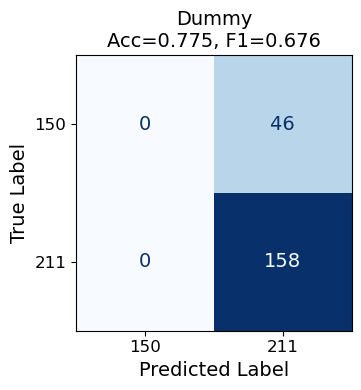


--- Logistic Regression (CV score: 0.8311) ---
Best params: {'clf__estimator__C': 10, 'clf__estimator__class_weight': 'balanced', 'clf__threshold': 0.8, 'feature_selector__feature_set': 'invariant', 'pca__n_components': 0.99}
OOF Accuracy: 0.833, OOF Weighted F1: 0.838


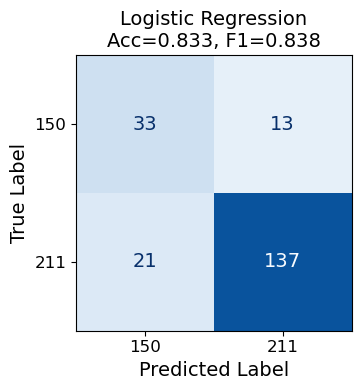


--- Random Forest (CV score: 0.7280) ---
Best params: {'clf__estimator__class_weight': None, 'clf__estimator__max_depth': None, 'clf__estimator__min_samples_leaf': 1, 'clf__threshold': 0.6, 'feature_selector__feature_set': 'cleaned+speed'}
OOF Accuracy: 0.824, OOF Weighted F1: 0.822


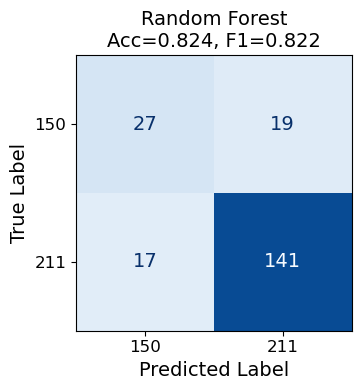


--- SVC (CV score: 0.7490) ---
Best params: {'clf__C': 10, 'clf__degree': 3, 'clf__gamma': 'scale', 'clf__kernel': 'poly', 'feature_selector__feature_set': 'cleaned'}
OOF Accuracy: 0.819, OOF Weighted F1: 0.776


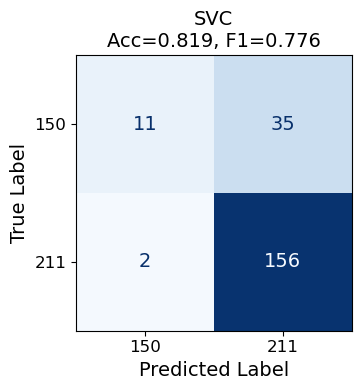


--- XGBoost (CV score: 0.7271) ---
Best params: {'clf__estimator__gamma': 0.1, 'clf__estimator__learning_rate': 0.1, 'clf__estimator__max_depth': 3, 'clf__estimator__min_child_weight': 1, 'clf__estimator__subsample': 0.8, 'clf__threshold': 0.2, 'feature_selector__feature_set': 'invariant'}
OOF Accuracy: 0.858, OOF Weighted F1: 0.847


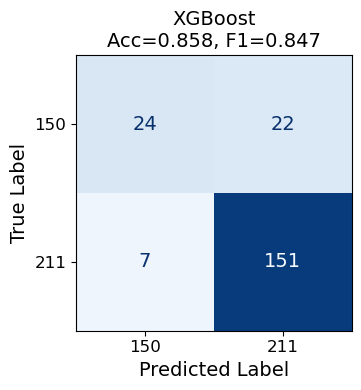


--- LightGBM (CV score: 0.7534) ---
Best params: {'clf__estimator__class_weight': 'balanced', 'clf__estimator__learning_rate': 0.05, 'clf__estimator__max_depth': 10, 'clf__estimator__num_leaves': 31, 'clf__threshold': 0.4, 'feature_selector__feature_set': 'cleaned_invariant'}
OOF Accuracy: 0.843, OOF Weighted F1: 0.843


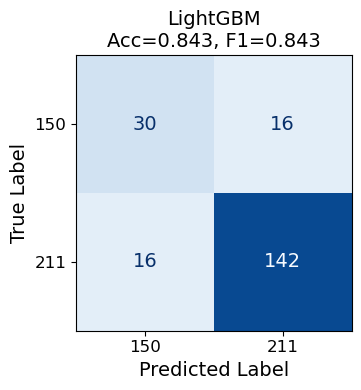


--- TabPFN (CV score: 0.8430) ---
Best params: {'clf__balance_probabilities': True, 'clf__n_estimators': 2, 'feature_selector__feature_set': 'cleaned_invariant+speed'}
OOF Accuracy: 0.882, OOF Weighted F1: 0.886


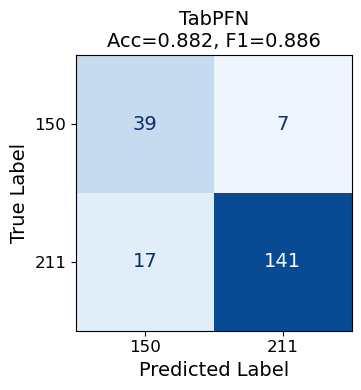


--- TabPFN Emb + RF (CV score: 0.8849) ---
Best params: {'clf__threshold': np.float64(0.6), 'embedding__n_estimators_tabpfn': np.int64(1), 'feature_selector__feature_set': 'cleaned'}
OOF Accuracy: 0.917, OOF Weighted F1: 0.919


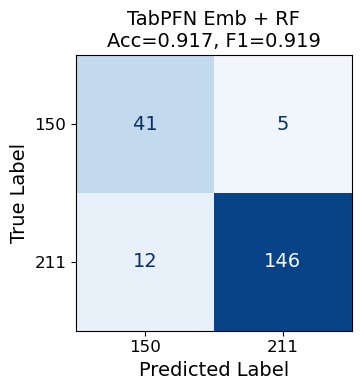


--- TabPFN Emb + XGB (CV score: 0.7580) ---
Best params: {'clf__estimator__learning_rate': 0.01, 'clf__estimator__max_depth': 3, 'clf__threshold': 0.2, 'embedding__n_estimators_tabpfn': 1, 'feature_selector__feature_set': 'cleaned'}
OOF Accuracy: 0.843, OOF Weighted F1: 0.809


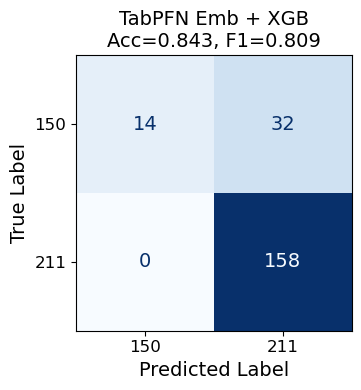


--- TabPFN Emb + LGBM (CV score: 0.8566) ---
Best params: {'clf__estimator__learning_rate': 0.01, 'clf__estimator__max_depth': 5, 'clf__estimator__num_leaves': 31, 'clf__threshold': 0.4, 'embedding__n_estimators_tabpfn': 1, 'feature_selector__feature_set': 'cleaned'}


/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF Accuracy: 0.892, OOF Weighted F1: 0.889


/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


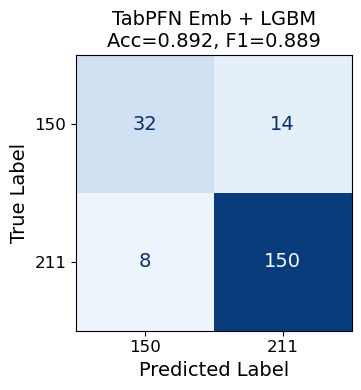


--- TabPFN Emb + LogReg PCA (CV score: 0.8843) ---
Best params: {'clf__estimator__C': 10, 'clf__estimator__class_weight': 'balanced', 'clf__threshold': 0.8, 'embedding__n_estimators_tabpfn': 1, 'feature_selector__feature_set': 'cleaned', 'pca__n_components': 0.8}
OOF Accuracy: 0.907, OOF Weighted F1: 0.910


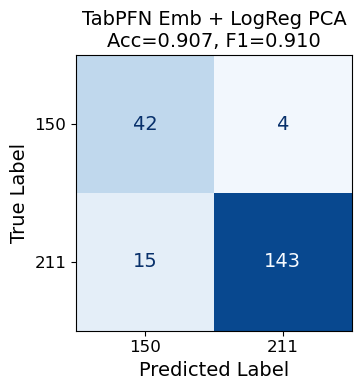


--- TabPFN Emb + SVC (CV score: 0.8132) ---
Best params: {'clf__C': 1, 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'poly', 'embedding__n_estimators_tabpfn': 1, 'feature_selector__feature_set': 'basic'}
OOF Accuracy: 0.892, OOF Weighted F1: 0.886


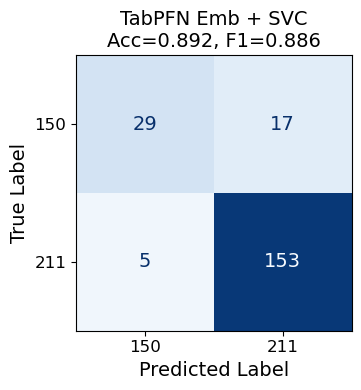

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

MODELS = {
    "Dummy": "dummy",
    "Logistic Regression": "log_reg",
    "Random Forest": "rf",
    "SVC": "svc",
    "XGBoost": "xgb",
    "LightGBM": "lgbm",
    "TabPFN": "tabpfn",
    "TabPFN Emb + RF": "tabpfn_emb_rf",
    "TabPFN Emb + XGB": "tabpfn_emb_xgb",
    "TabPFN Emb + LGBM": "tabpfn_emb_lgbm",
    "TabPFN Emb + LogReg PCA": "tabpfn_emb_log_reg",
    "TabPFN Emb + SVC": "tabpfn_emb_svc",
}

# TabPFN embedding models are not picklable → must use n_jobs=1
EMBEDDING_MODELS = {
    "tabpfn_emb_rf",
    "tabpfn_emb_xgb",
    "tabpfn_emb_lgbm",
    "tabpfn_emb_log_reg",
    "tabpfn_emb_svc",
}

results_dir = ROOT_DIR / "results"

for display_name, model_key in MODELS.items():
    pipeline, best_params, cv_score = build_best_pipeline(
        model_key, LOGO_COLUMN, FEATURE_SETS, results_dir
    )

    print(f"\n--- {display_name} (CV score: {cv_score:.4f}) ---")
    print(f"Best params: {best_params}")

    n_jobs = 1 if model_key in EMBEDDING_MODELS else -1

    # Out-of-fold predictions via LOGO CV
    y_pred = cross_val_predict(
        pipeline,
        X,
        y_enc,
        cv=logo.split(X, y_enc, groups),
        n_jobs=n_jobs,
    )

    acc = accuracy_score(y_enc, y_pred)
    f1 = f1_score(y_enc, y_pred, average="weighted")
    print(f"OOF Accuracy: {acc:.3f}, OOF Weighted F1: {f1:.3f}")

    cm = confusion_matrix(y_enc, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        text_kw={"fontsize": 14},
        im_kw={"vmin": 0, "vmax": 158},
    )
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.set_xlabel("Predicted Label", fontsize=14)
    ax.set_ylabel("True Label", fontsize=14)
    ax.set_title(f"{display_name}\nAcc={acc:.3f}, F1={f1:.3f}", fontsize=14)
    plt.tight_layout()
    plt.savefig(
        ROOT_DIR / "plots" / f"cm_{model_key}_logo_{LOGO_COLUMN}.pdf",
        bbox_inches="tight",
    )
    plt.show()

## Visualize Results

In [45]:
# Dynamically load all model result CSVs for the current LOGO_COLUMN
results_dir = ROOT_DIR / "results"
pattern = f"*_logo_{LOGO_COLUMN}_results.csv"

res_dfs = []
for csv_path in sorted(results_dir.glob(pattern)):
    df_res = pd.read_csv(csv_path)
    # Extract model name from filename: e.g. "rf_logo_vehicle_results.csv" → "rf"
    model_name = csv_path.stem.replace(f"_logo_{LOGO_COLUMN}_results", "")
    df_res["model"] = model_name
    res_dfs.append(df_res)

res_df = pd.concat(res_dfs, ignore_index=True)
print(f"Loaded {len(res_dfs)} result files: {[d['model'].iloc[0] for d in res_dfs]}")

res_df.to_csv(results_dir / f"{LOGO_COLUMN}_logo_results.csv", index=False)
res_df

Loaded 12 result files: ['dummy', 'lgbm', 'log_reg', 'rf', 'svc', 'tabpfn_emb_lgbm', 'tabpfn_emb_log_reg', 'tabpfn_emb_rf', 'tabpfn_emb_svc', 'tabpfn_emb_xgb', 'tabpfn', 'xgb']


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_feature_selector__feature_set,params,split0_test_weighted_f1,split1_test_weighted_f1,split2_test_weighted_f1,split3_test_weighted_f1,...,param_clf__degree,param_clf__gamma,param_clf__kernel,param_embedding__n_estimators_tabpfn,param_clf__estimator,param_clf__balance_probabilities,param_clf__n_estimators,param_clf__estimator__gamma,param_clf__estimator__min_child_weight,param_clf__estimator__subsample
0,0.010037,0.004652,0.005113,0.003734,basic,{'feature_selector__feature_set': 'basic'},0.450000,0.851007,0.595238,0.533333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.007278,0.003719,0.006035,0.003682,cleaned,{'feature_selector__feature_set': 'cleaned'},0.450000,0.851007,0.595238,0.533333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.004776,0.000506,0.002697,0.000144,cleaned+speed,{'feature_selector__feature_set': 'cleaned+spe...,0.450000,0.851007,0.595238,0.533333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.004101,0.000220,0.002068,0.000103,invariant,{'feature_selector__feature_set': 'invariant'},0.450000,0.851007,0.595238,0.533333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.004185,0.000156,0.002078,0.000054,cleaned_invariant,{'feature_selector__feature_set': 'cleaned_inv...,0.450000,0.851007,0.595238,0.533333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10981,0.902465,0.063492,0.027793,0.005405,cleaned,"{'clf__estimator__gamma': 0.1, 'clf__estimator...",0.508772,0.630634,0.492501,0.488889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,5.0,1.0
10982,0.770802,0.088011,0.040439,0.011706,cleaned+speed,"{'clf__estimator__gamma': 0.1, 'clf__estimator...",0.430769,0.641090,0.471458,0.488889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,5.0,1.0
10983,0.659767,0.060914,0.029276,0.006038,invariant,"{'clf__estimator__gamma': 0.1, 'clf__estimator...",0.430769,0.720015,0.471458,0.462719,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,5.0,1.0
10984,0.779872,0.092583,0.066150,0.081738,cleaned_invariant,"{'clf__estimator__gamma': 0.1, 'clf__estimator...",0.508772,0.661578,0.449820,0.539087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,5.0,1.0


### Balancing Helper

In [ ]:
def car_balanced_weights(vehicles):
    counts = Counter(vehicles)
    w = np.array([1.0 / counts[c] for c in vehicles], dtype=float)
    # normalize for nicer scales (optional)
    return w * (len(w) / w.sum())

### Training Loop

In [ ]:
# Config
CLASS_BALANCING = False
CAR_BALANCING = True
THRESHOLD_TUNING = True  # Only for Random Forest

In [ ]:
rf_accs, rf_f1s = [], []
xgb_accs, xgb_f1s = [], []
lgbm_accs, lgbm_f1s = [], []
tabpfn_accs, tabpfn_f1s = [], []
fold_results = []

# Optional: to accumulate global confusion matrices across folds
# (nice for seminar slides)
labels = le.classes_
rf_cm_total = np.zeros((len(labels), len(labels)), dtype=int)
xgb_cm_total = np.zeros_like(rf_cm_total)
lgbm_cm_total = np.zeros_like(rf_cm_total)
tabpfn_cm_total = np.zeros_like(rf_cm_total)

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups), start=1):
    held_out_car = groups[test_idx][0]
    print(f"\n===== LOGO Fold {fold} | Held-out car: {held_out_car} =====")
    print(f"Train n={len(train_idx)}, Test n={len(test_idx)}")

    # Split data (enc for XGBoost)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    y_train_enc, y_test_enc = y_enc[train_idx], y_enc[test_idx]

    # Compute class weights
    class_weights = compute_sample_weight("balanced", y_train)

    # Compute car-based weights to balance training samples by car
    car_train = df_clean.iloc[train_idx]["vehicle"].to_numpy()
    car_weights = car_balanced_weights(car_train)

    # ------------------ Random Forest ------------------
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42,
    )

    # Fit with appropriate sample weights
    if CLASS_BALANCING and CAR_BALANCING:
        combined_weights = class_weights * car_weights
        combined_weights = combined_weights * (len(combined_weights) / combined_weights.sum())
        rf.fit(X_train, y_train, sample_weight=combined_weights)
    elif CLASS_BALANCING:
        rf.fit(X_train, y_train, sample_weight=class_weights)
    elif CAR_BALANCING:
        rf.fit(X_train, y_train, sample_weight=car_weights)
    else:
        rf.fit(X_train, y_train)

    # Threshold tuning
    if THRESHOLD_TUNING:
        proba0 = rf.predict_proba(X_test)[:, 0]
        t0 = 0.3  # threshold for class 0
        y_pred_rf_enc = (proba0 < t0).astype(int)
        y_pred_rf = le.inverse_transform(y_pred_rf_enc)
    else:
        y_pred_rf = rf.predict(X_test)

    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

    rf_accs.append(rf_acc)
    rf_f1s.append(rf_f1)

    cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)
    rf_cm_total += cm_rf

    print(f"RF  - acc: {rf_acc:.3f}, f1: {rf_f1:.3f}")
    print(cm_rf)

    # ------------------ XGBoost ------------------
    # For 2-class problems we can use binary:logistic.
    # If we ever add more road types, switch to multi:softprob + num_class.
    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        n_jobs=-1,
        eval_metric="logloss",
        random_state=42,
    )

    if CLASS_BALANCING and CAR_BALANCING:
        xgb.fit(X_train, y_train_enc, sample_weight=combined_weights)
    elif CLASS_BALANCING:
        xgb.fit(X_train, y_train_enc, sample_weight=class_weights)
    elif CAR_BALANCING:
        xgb.fit(X_train, y_train_enc, sample_weight=car_weights)
    else:
        xgb.fit(X_train, y_train_enc)

    y_pred_xgb_enc = xgb.predict(X_test)
    y_pred_xgb = le.inverse_transform(y_pred_xgb_enc.astype(int))

    xgb_acc = accuracy_score(y_test, y_pred_xgb)
    xgb_f1 = f1_score(y_test, y_pred_xgb, average="weighted")

    xgb_accs.append(xgb_acc)
    xgb_f1s.append(xgb_f1)

    cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels)
    xgb_cm_total += cm_xgb

    print(f"XGB - acc: {xgb_acc:.3f}, f1: {xgb_f1:.3f}")
    print(cm_xgb)

    # ------------------ LightGBM ------------------
    lgbm = LGBMClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

    if CLASS_BALANCING and CAR_BALANCING:
        lgbm.fit(X_train, y_train_enc, sample_weight=combined_weights)
    elif CLASS_BALANCING:
        lgbm.fit(X_train, y_train_enc, sample_weight=class_weights)
    elif CAR_BALANCING:
        lgbm.fit(X_train, y_train_enc, sample_weight=car_weights)
    else:
        lgbm.fit(X_train, y_train_enc)

    if THRESHOLD_TUNING:
        proba0 = lgbm.predict_proba(X_test)[:, 0]
        t0 = 0.3  # threshold for class 0
        y_pred_lgbm_enc = (proba0 < t0).astype(int)
        y_pred_lgbm = le.inverse_transform(y_pred_lgbm_enc)
    else:
        y_pred_lgbm_enc = lgbm.predict(X_test)
        y_pred_lgbm = le.inverse_transform(y_pred_lgbm_enc.astype(int))

    lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
    lgbm_f1 = f1_score(y_test, y_pred_lgbm, average="weighted")

    lgbm_accs.append(lgbm_acc)
    lgbm_f1s.append(lgbm_f1)

    cm_lgbm = confusion_matrix(y_test, y_pred_lgbm, labels=labels)
    lgbm_cm_total += cm_lgbm

    print(f"LGBM - acc: {lgbm_acc:.3f}, f1: {lgbm_f1:.3f}")
    print(cm_lgbm)

    # ------------------ TabPFN ------------------
    tabpfn = TabPFNClassifier()
    tabpfn.fit(X_train, y_train_enc)

    if THRESHOLD_TUNING:
        proba0 = tabpfn.predict_proba(X_test)[:, 0]
        t0 = 0.3  # threshold for class 0
        y_pred_tabpfn_enc = (proba0 < t0).astype(int)
        y_pred_tabpfn = le.inverse_transform(y_pred_tabpfn_enc)
    else:
        y_pred_tabpfn_enc = tabpfn.predict(X_test)
    y_pred_tabpfn = le.inverse_transform(y_pred_tabpfn_enc.astype(int))

    tabpfn_acc = accuracy_score(y_test, y_pred_tabpfn)
    tabpfn_f1 = f1_score(y_test, y_pred_tabpfn, average="weighted")

    tabpfn_accs.append(tabpfn_acc)
    tabpfn_f1s.append(tabpfn_f1)

    cm_tabpfn = confusion_matrix(y_test, y_pred_tabpfn, labels=labels)
    tabpfn_cm_total += cm_tabpfn

    print(f"TabPFN - acc: {tabpfn_acc:.3f}, f1: {tabpfn_f1:.3f}")
    print(cm_tabpfn)

    fold_results.append(
        {
            "fold": fold,
            "held_out_car": held_out_car,
            "n_test": len(test_idx),
            "rf_acc": rf_acc,
            "rf_f1": rf_f1,
            "xgb_acc": xgb_acc,
            "xgb_f1": xgb_f1,
            "lgbm_acc": lgbm_acc,
            "lgbm_f1": lgbm_f1,
            "tabpfn_acc": tabpfn_acc,
            "tabpfn_f1": tabpfn_f1,
        }
    )


# --------------- Summary ---------------
print("\n===== LOGO Summary (per held-out car) =====")
for r in fold_results:
    print(
        f"{r['held_out_car']}: RF acc={r['rf_acc']:.3f}, XGB acc={r['xgb_acc']:.3f}, "
        f"LGBM acc={r['lgbm_acc']:.3f}, TabPFN acc={r['tabpfn_acc']:.3f}"
    )

print("\n===== Overall (mean ± std) =====")
print(
    f"RF  acc: {np.mean(rf_accs):.3f} ± {np.std(rf_accs):.3f} | "
    f"f1: {np.mean(rf_f1s):.3f} ± {np.std(rf_f1s):.3f}"
)
print(
    f"XGB acc: {np.mean(xgb_accs):.3f} ± {np.std(xgb_accs):.3f} | "
    f"f1: {np.mean(xgb_f1s):.3f} ± {np.std(xgb_f1s):.3f}"
)
print(
    f"LGBM acc: {np.mean(lgbm_accs):.3f} ± {np.std(lgbm_accs):.3f} | "
    f"f1: {np.mean(lgbm_f1s):.3f} ± {np.std(lgbm_f1s):.3f}"
)
print(
    f"TabPFN acc: {np.mean(tabpfn_accs):.3f} ± {np.std(tabpfn_accs):.3f} | "
    f"f1: {np.mean(tabpfn_f1s):.3f} ± {np.std(tabpfn_f1s):.3f}"
)

print("\nRF total confusion matrix (rows=true, cols=pred):")
print(rf_cm_total)
print("\nXGB total confusion matrix (rows=true, cols=pred):")
print(xgb_cm_total)
print("\nLGBM total confusion matrix (rows=true, cols=pred):")
print(lgbm_cm_total)
print("\nTabPFN total confusion matrix (rows=true, cols=pred):")
print(tabpfn_cm_total)
print("\nLabel order:", labels)

### Feature Importance

In [ ]:
rf_final = RandomForestClassifier(n_estimators=500, max_depth=None, n_jobs=-1, random_state=42)

# Compute class weights
class_weights_final = compute_sample_weight("balanced", y)

# Compute car-based weights to balance training samples by car
car_final = df_clean["vehicle"].to_numpy()
car_weights_final = car_balanced_weights(car_final)
if CLASS_BALANCING and CAR_BALANCING:
    combined_weights_final = class_weights_final * car_weights_final
    combined_weights_final = combined_weights_final * (
        len(combined_weights_final) / combined_weights_final.sum()
    )
    rf_final.fit(X, y, sample_weight=combined_weights_final)
elif CLASS_BALANCING:
    rf_final.fit(X, y, sample_weight=class_weights_final)
elif CAR_BALANCING:
    rf_final.fit(X, y, sample_weight=car_weights_final)
else:
    rf_final.fit(X, y)

importances_rf = pd.Series(rf_final.feature_importances_, index=feature_cols)
print("\nTop 20 features Random Forest:")
print(importances_rf.sort_values(ascending=False).head(20))

In [ ]:
xgb_final = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    n_jobs=-1,
    eval_metric="logloss",
    random_state=42,
)

if CLASS_BALANCING and CAR_BALANCING:
    xgb_final.fit(X, y_enc, sample_weight=combined_weights_final)
elif CLASS_BALANCING:
    xgb_final.fit(X, y_enc, sample_weight=class_weights_final)
elif CAR_BALANCING:
    xgb_final.fit(X, y_enc, sample_weight=car_weights_final)
else:
    xgb_final.fit(X, y_enc)

xgb_feature_scores = xgb_final.get_booster().get_score(importance_type="gain")

# Convert to pandas Series
importances_xgb = (
    pd.Series(xgb_feature_scores)
    .rename(index=lambda x: feature_cols[int(x[1:])])  # maps f0 → feature name
    .sort_values(ascending=False)
)

xgb_norm = importances_xgb / importances_xgb.sum()
print("\nTop 20 features XGBoost:")
print(xgb_norm.head(20))

In [ ]:
lgbm_final = LGBMClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

if CLASS_BALANCING and CAR_BALANCING:
    lgbm_final.fit(X, y_enc, sample_weight=combined_weights_final)
elif CLASS_BALANCING:
    lgbm_final.fit(X, y_enc, sample_weight=class_weights_final)
elif CAR_BALANCING:
    lgbm_final.fit(X, y_enc, sample_weight=car_weights_final)
else:
    lgbm_final.fit(X, y_enc)

importances_lgbm = pd.Series(lgbm_final.feature_importances_, index=feature_cols)
print("\nTop 20 features LightGBM:")
print(importances_lgbm.sort_values(ascending=False).head(20))